In [3]:
data <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/kreatin.dat")
data <- ts(data[["V2"]][2:(length((data[["V2"]])))])
data <- as.numeric(data)

In [4]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

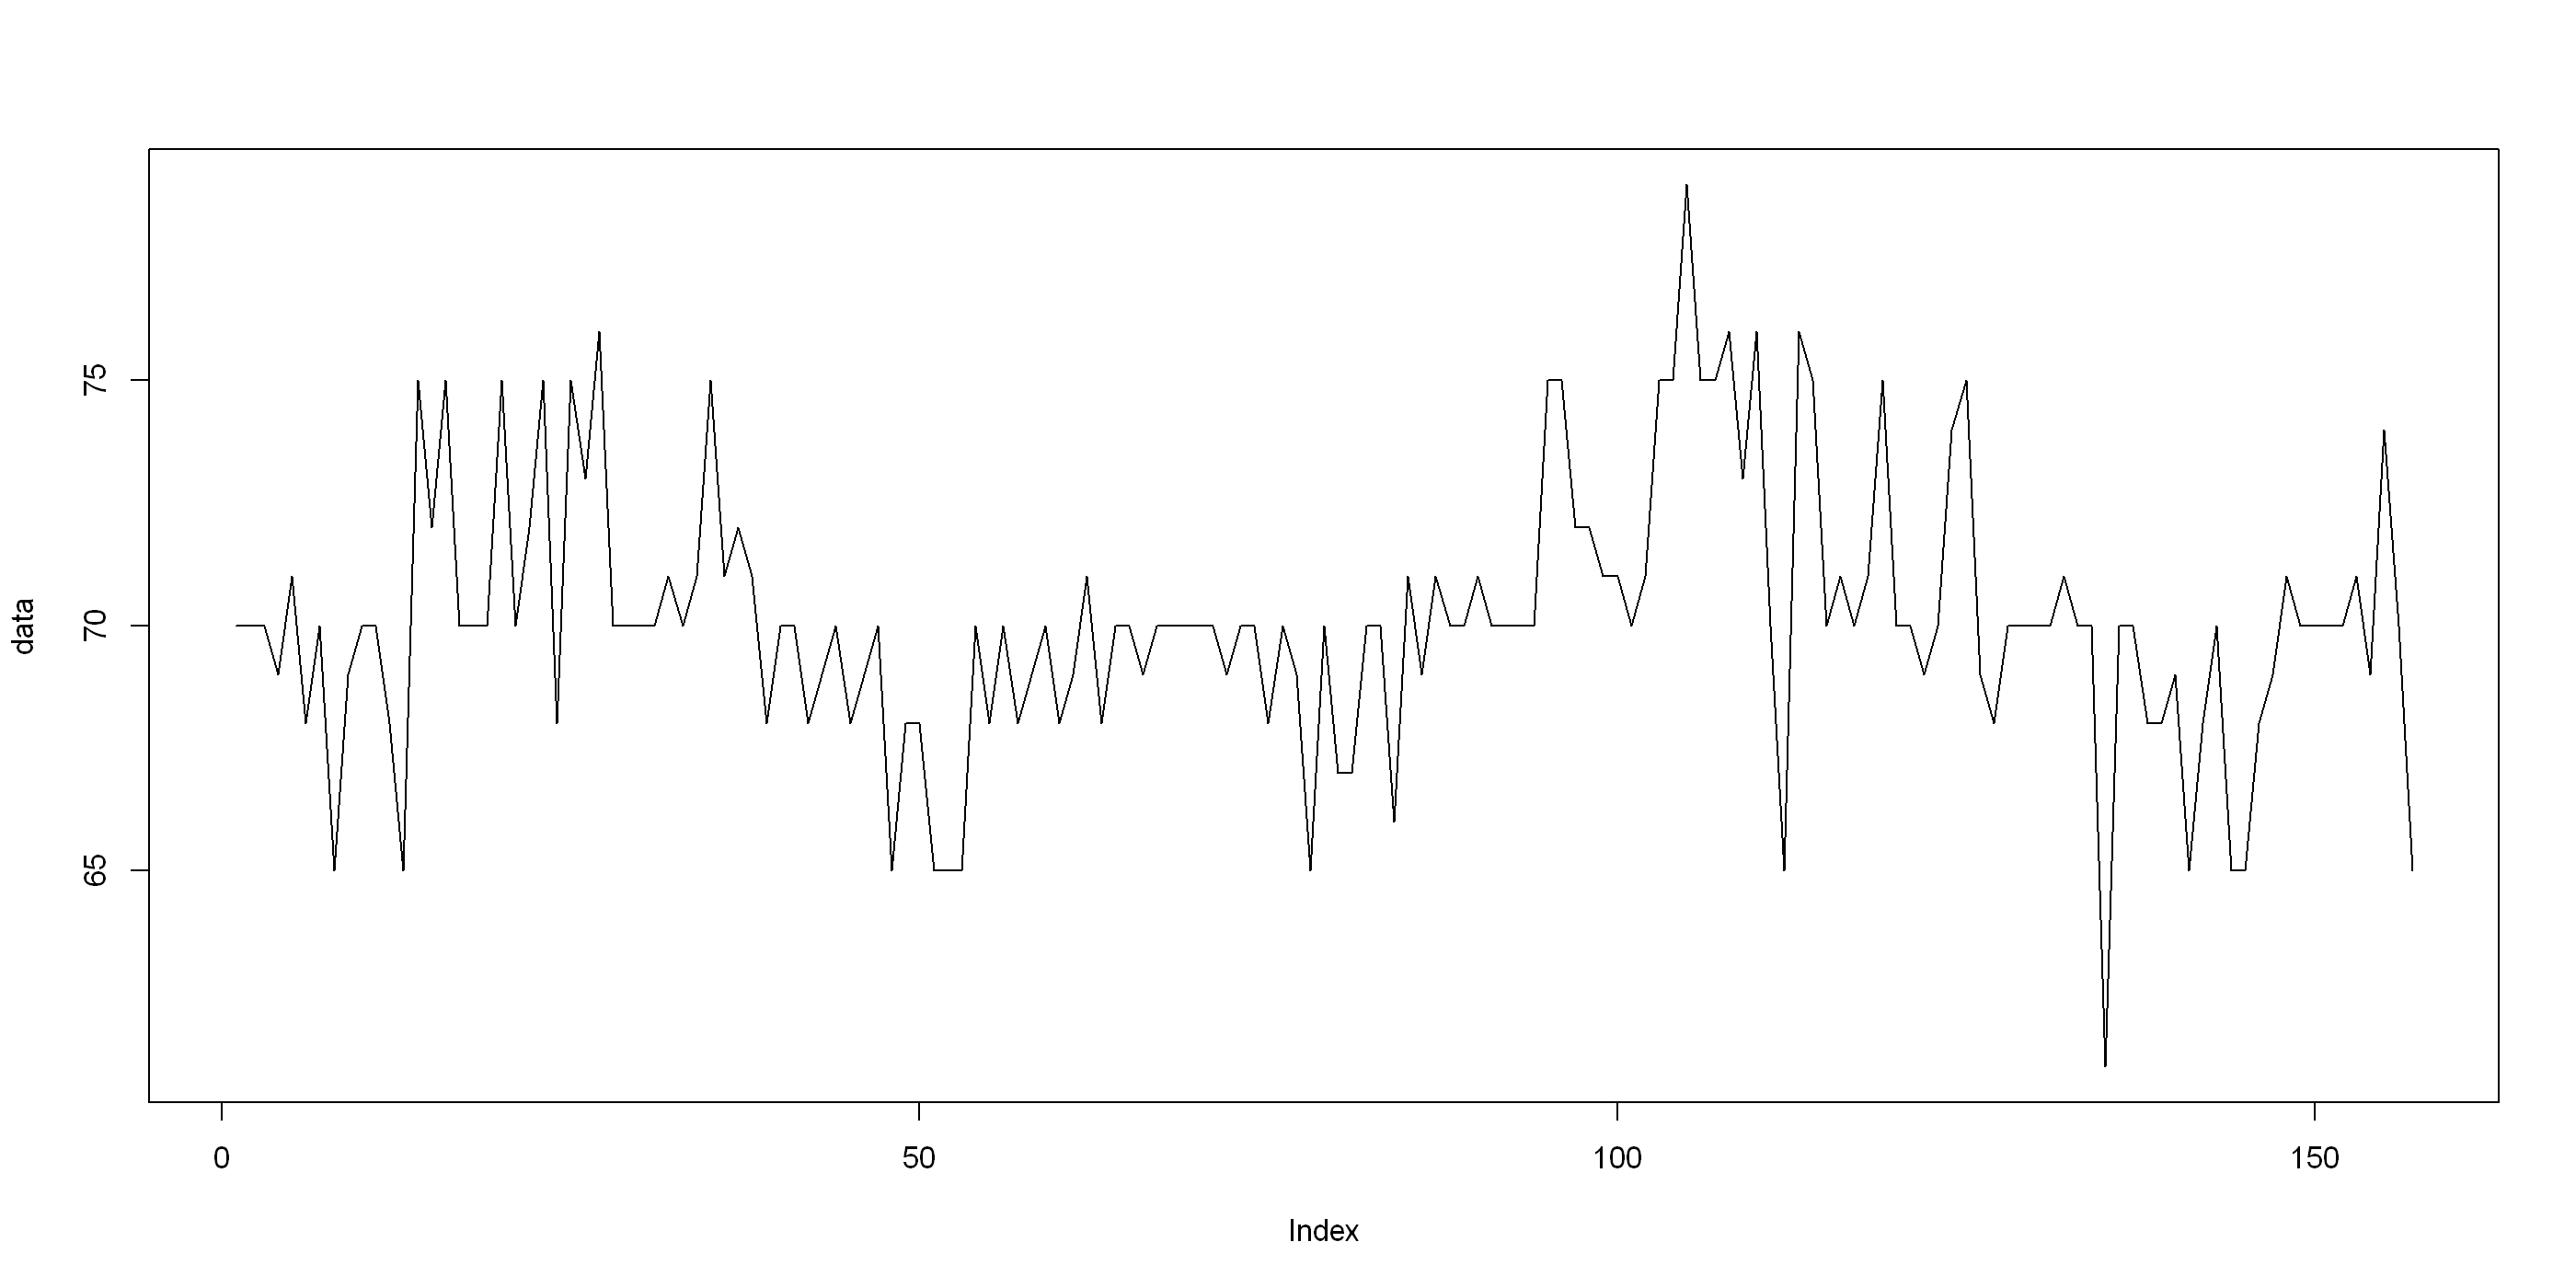

In [5]:
plot(data,type="l")

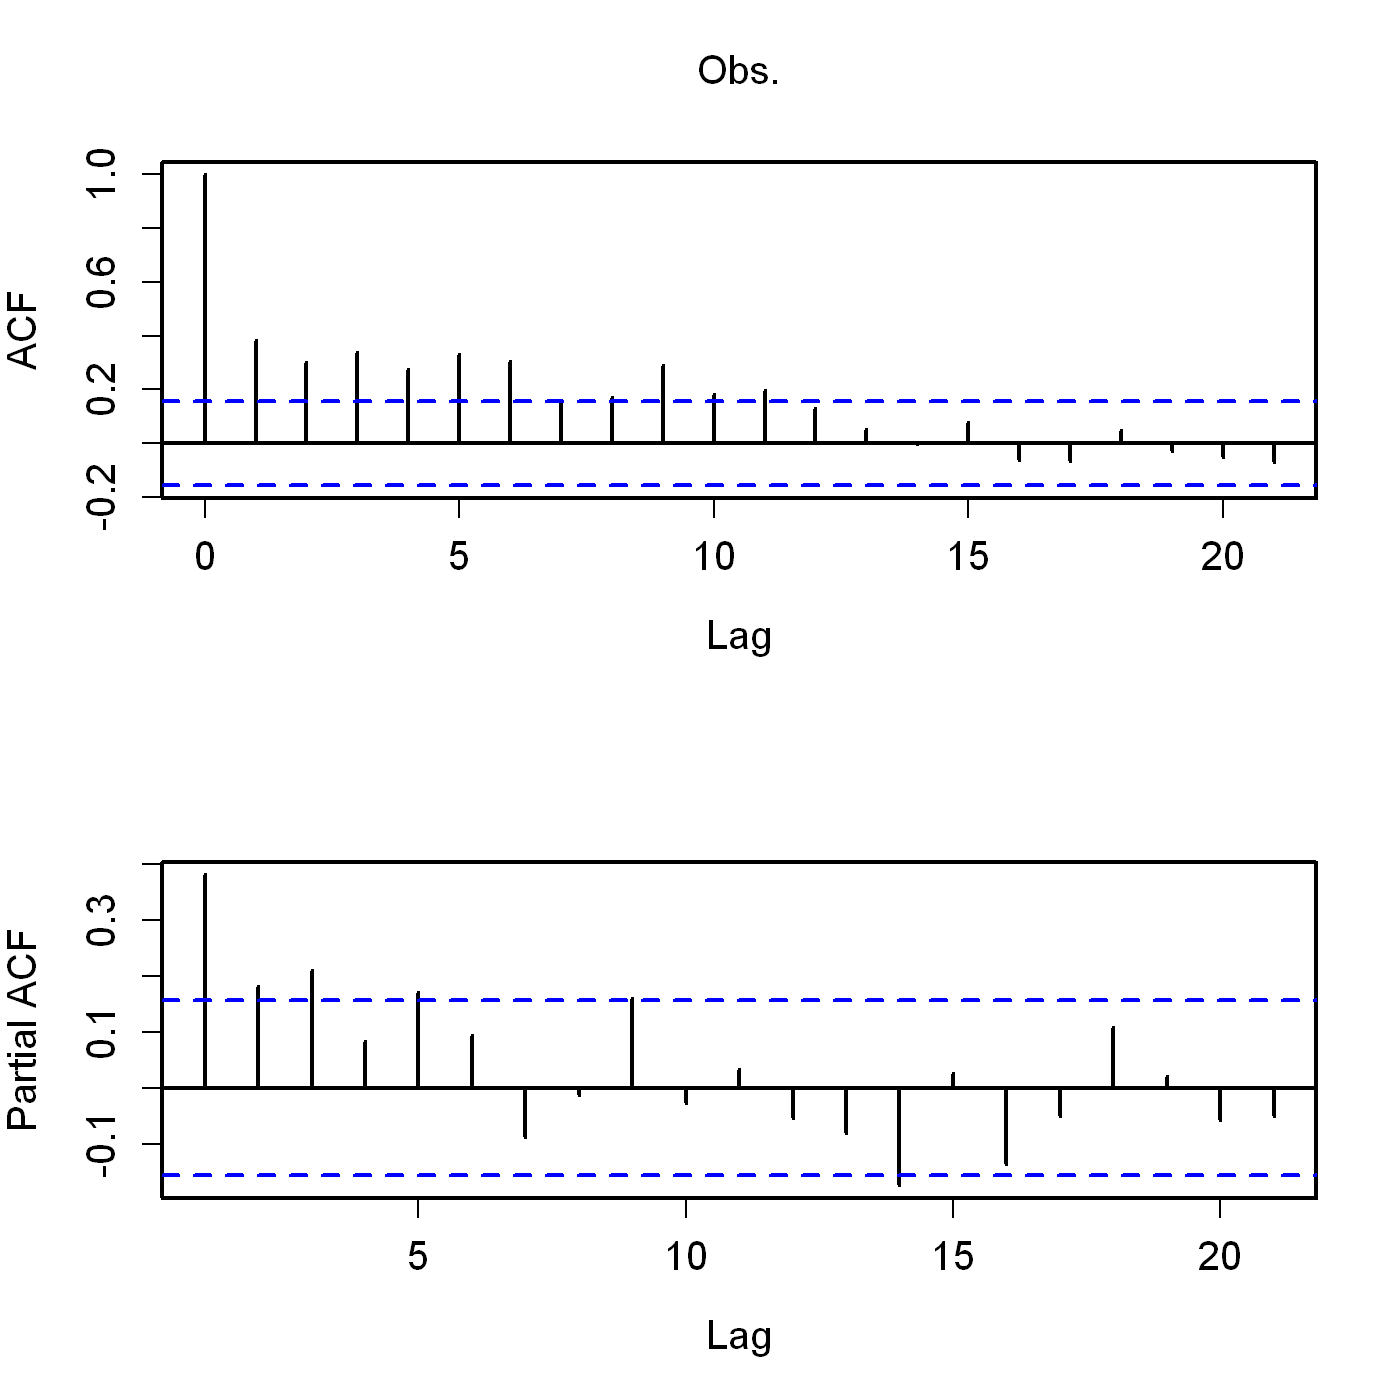

In [28]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)
par(mfrow=c(2,1),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
acf(data,main="Obs.")
pacf(data,main="")

In [7]:
d.force <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/kraft.dat",
header = FALSE)
ts.force <- ts(d.force[,1])
ts.forceA <- window(ts.force,end=280)

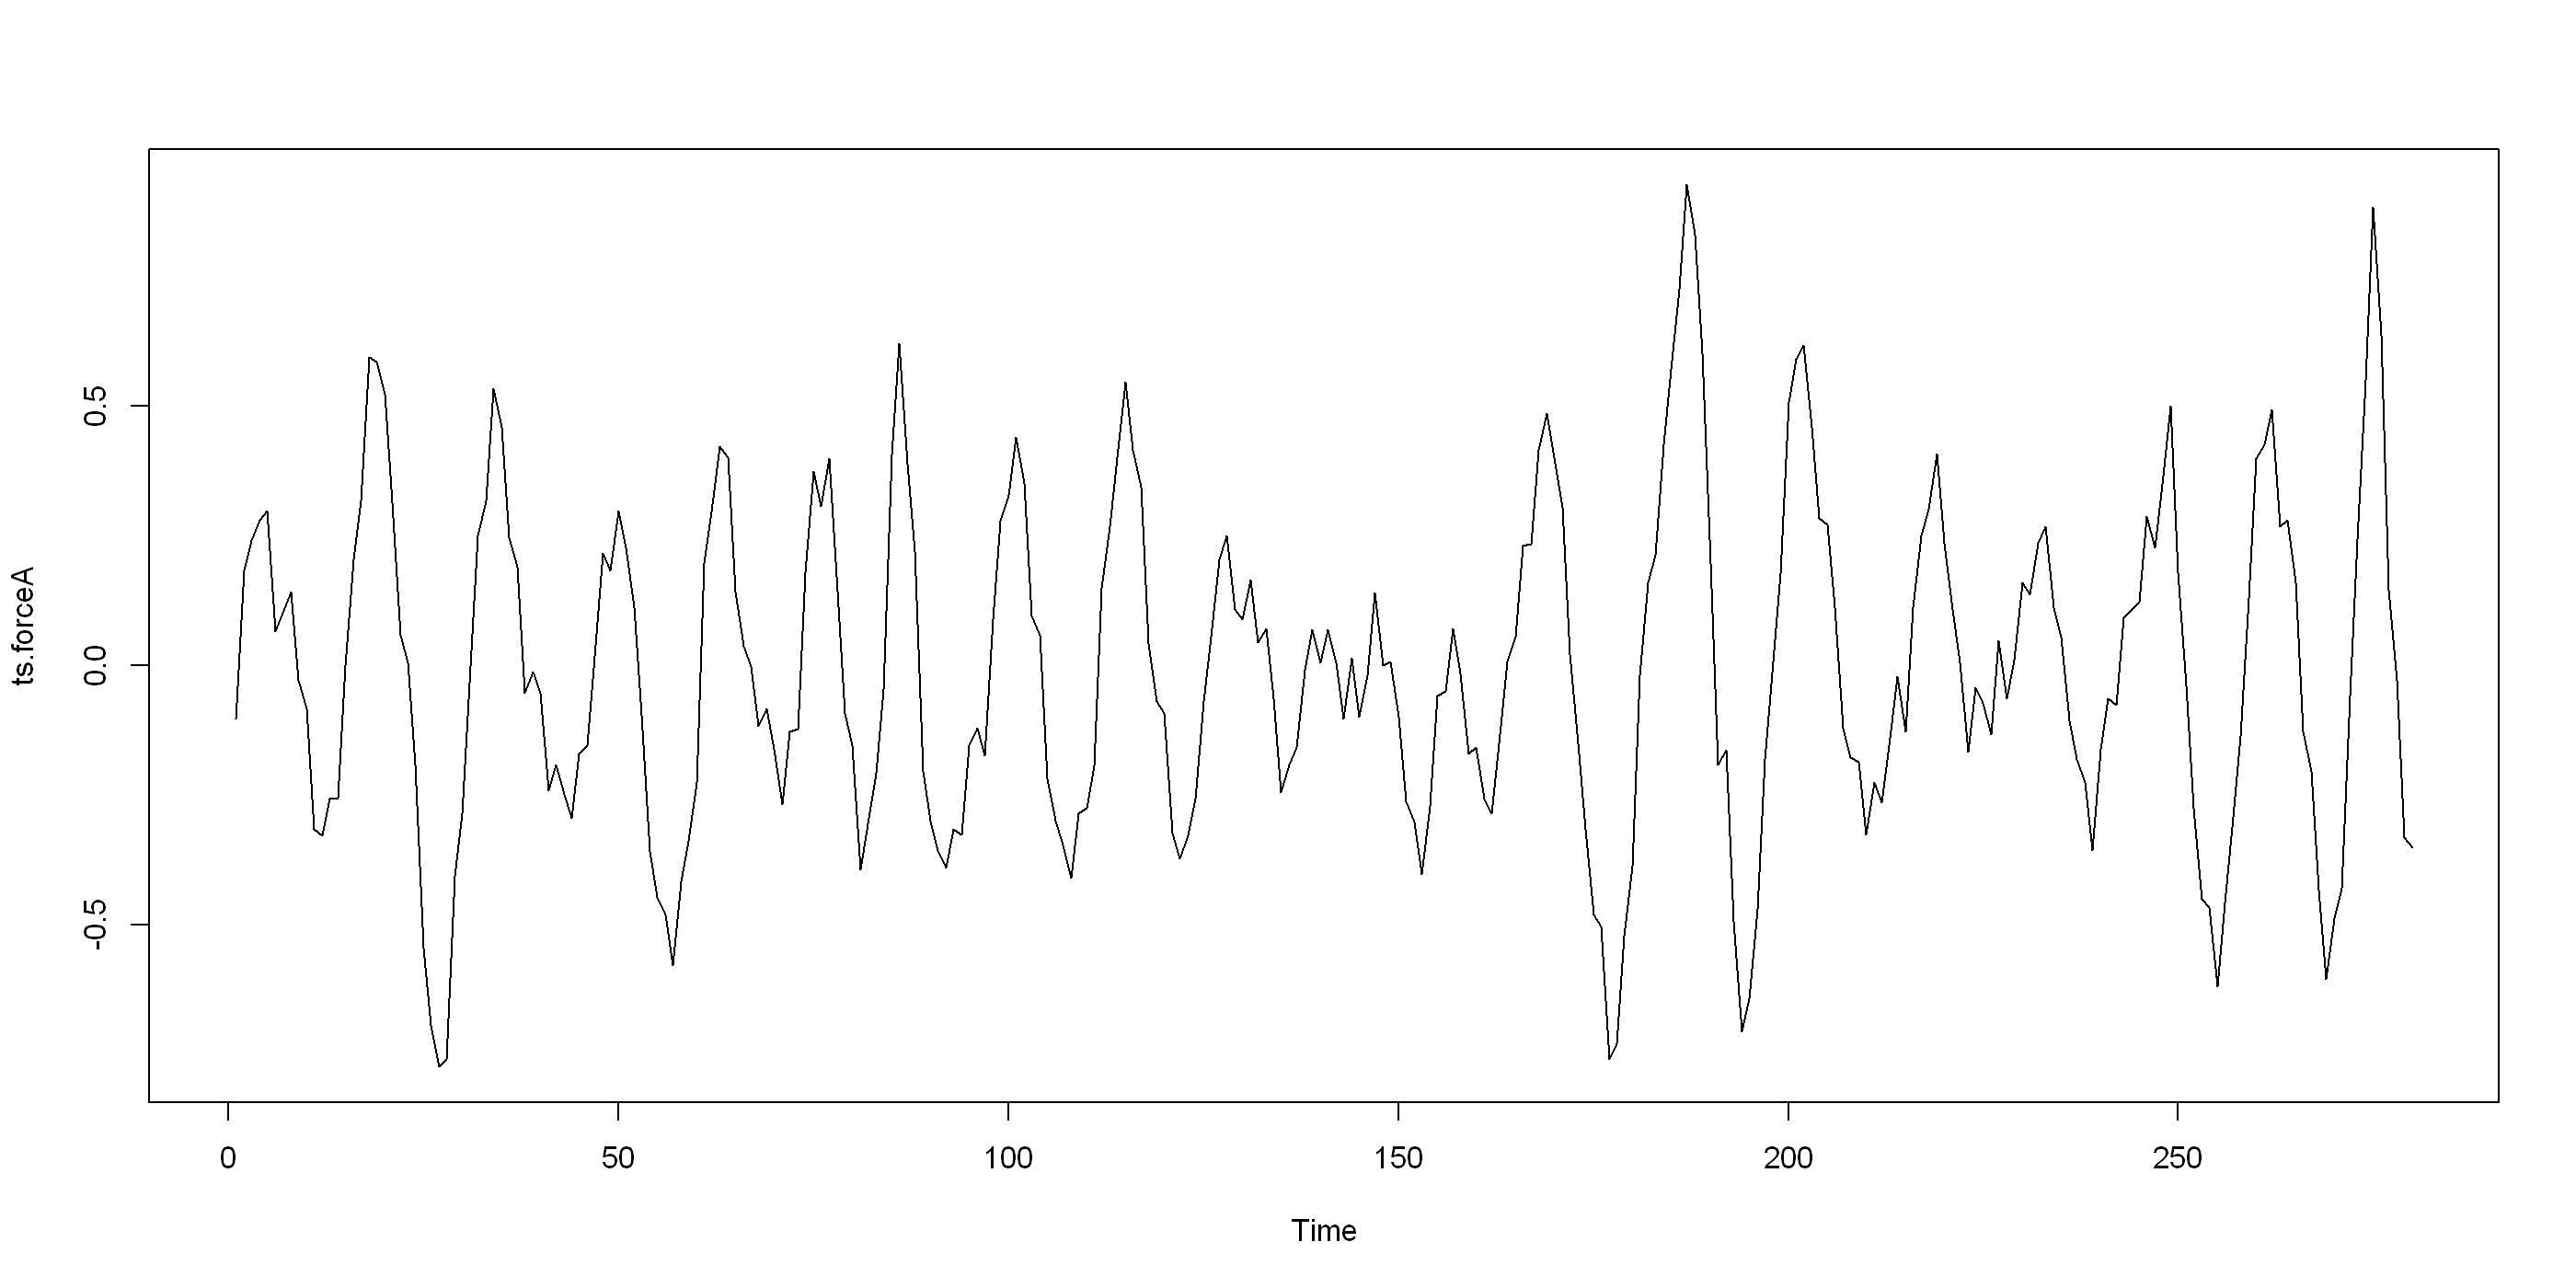

In [8]:
plot(ts.forceA)

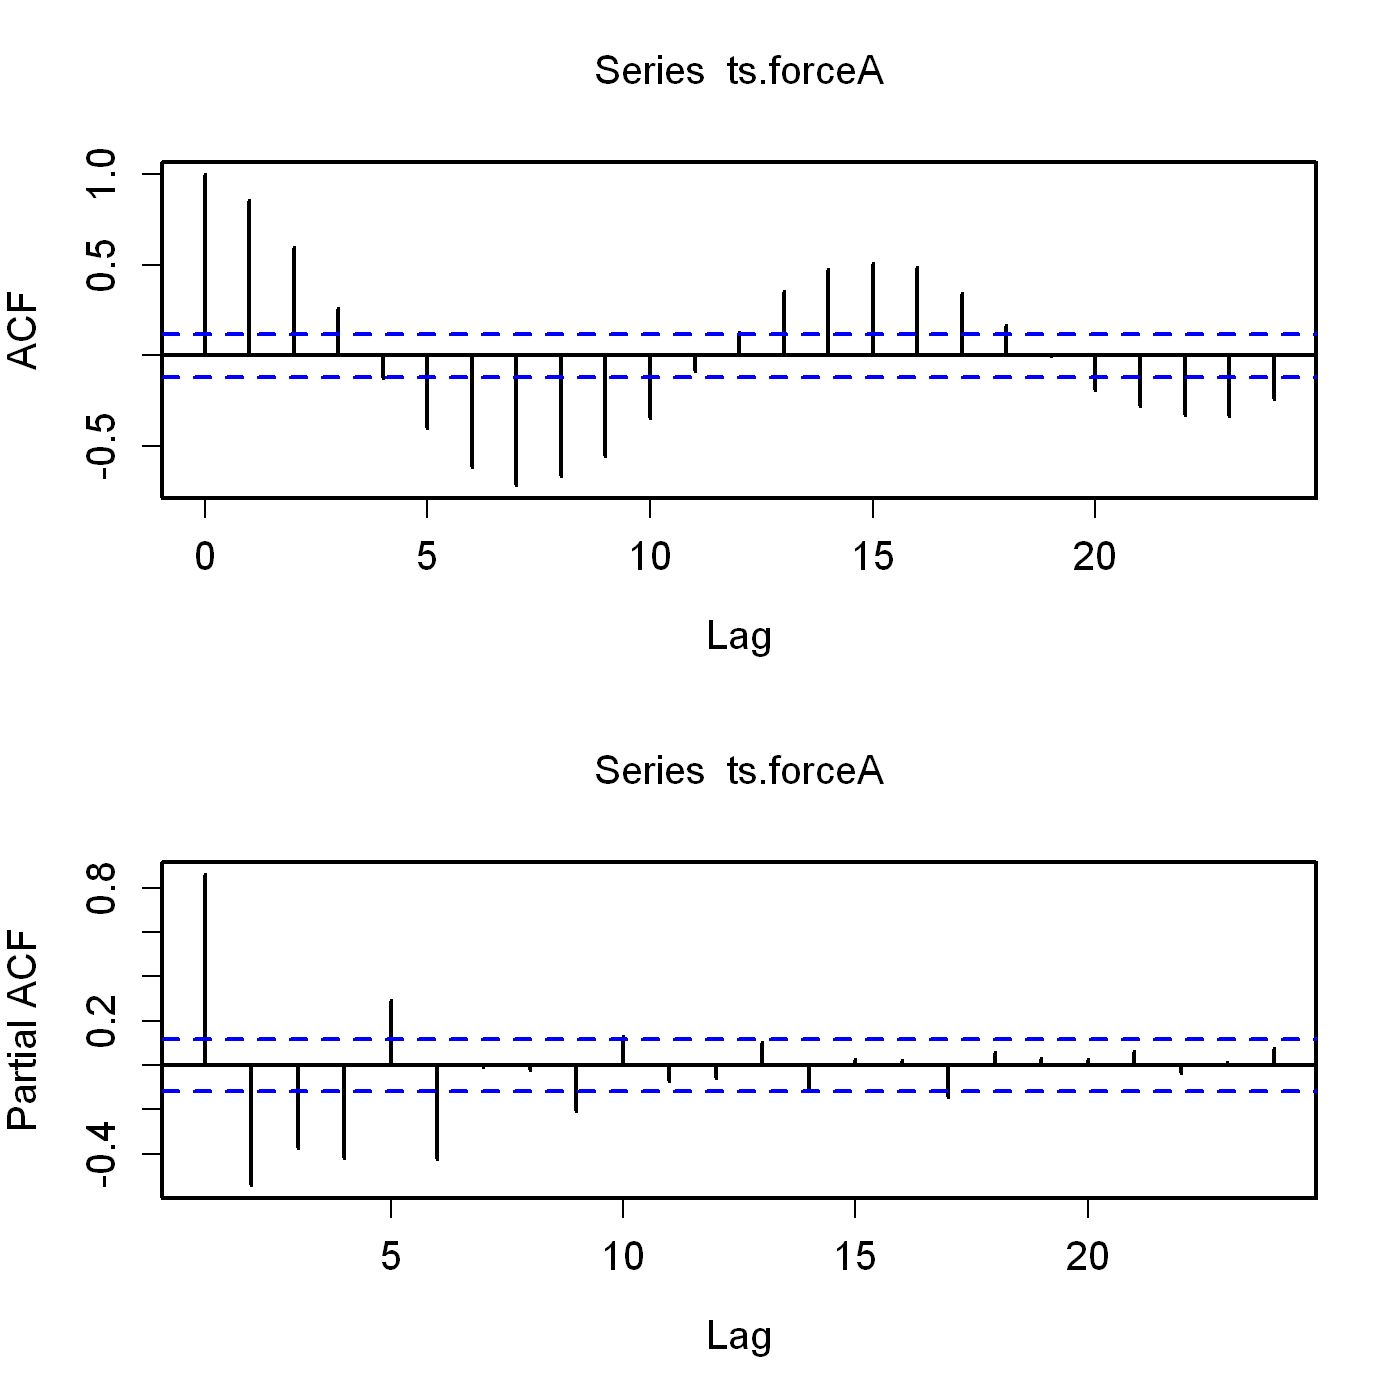

In [9]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)
par(mfrow=c(2,1),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
acf(ts.forceA)
pacf(ts.forceA)

In [10]:
ar.force <- ar(ts.forceA,method = "mle",order.max = 20)
print(ar.force$aic)

          0           1           2           3           4           5 
682.2938670 304.8169648 204.5116770 159.9380765 103.9357477  81.6655065 
          6           7           8           9          10          11 
 24.5738448  26.3441556  28.2684445  12.7645639   6.9096590   8.3556493 
         12          13          14          15          16          17 
  8.1408964   6.0205717   3.7357465   5.6870111   7.4389476   0.0000000 
         18          19          20 
  0.4112798   2.1647547   4.1261498 


In [11]:
p<-17
ar.force <- arima(ts.forceA,order=c(p,0,0),method="ML")

In [12]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 200)

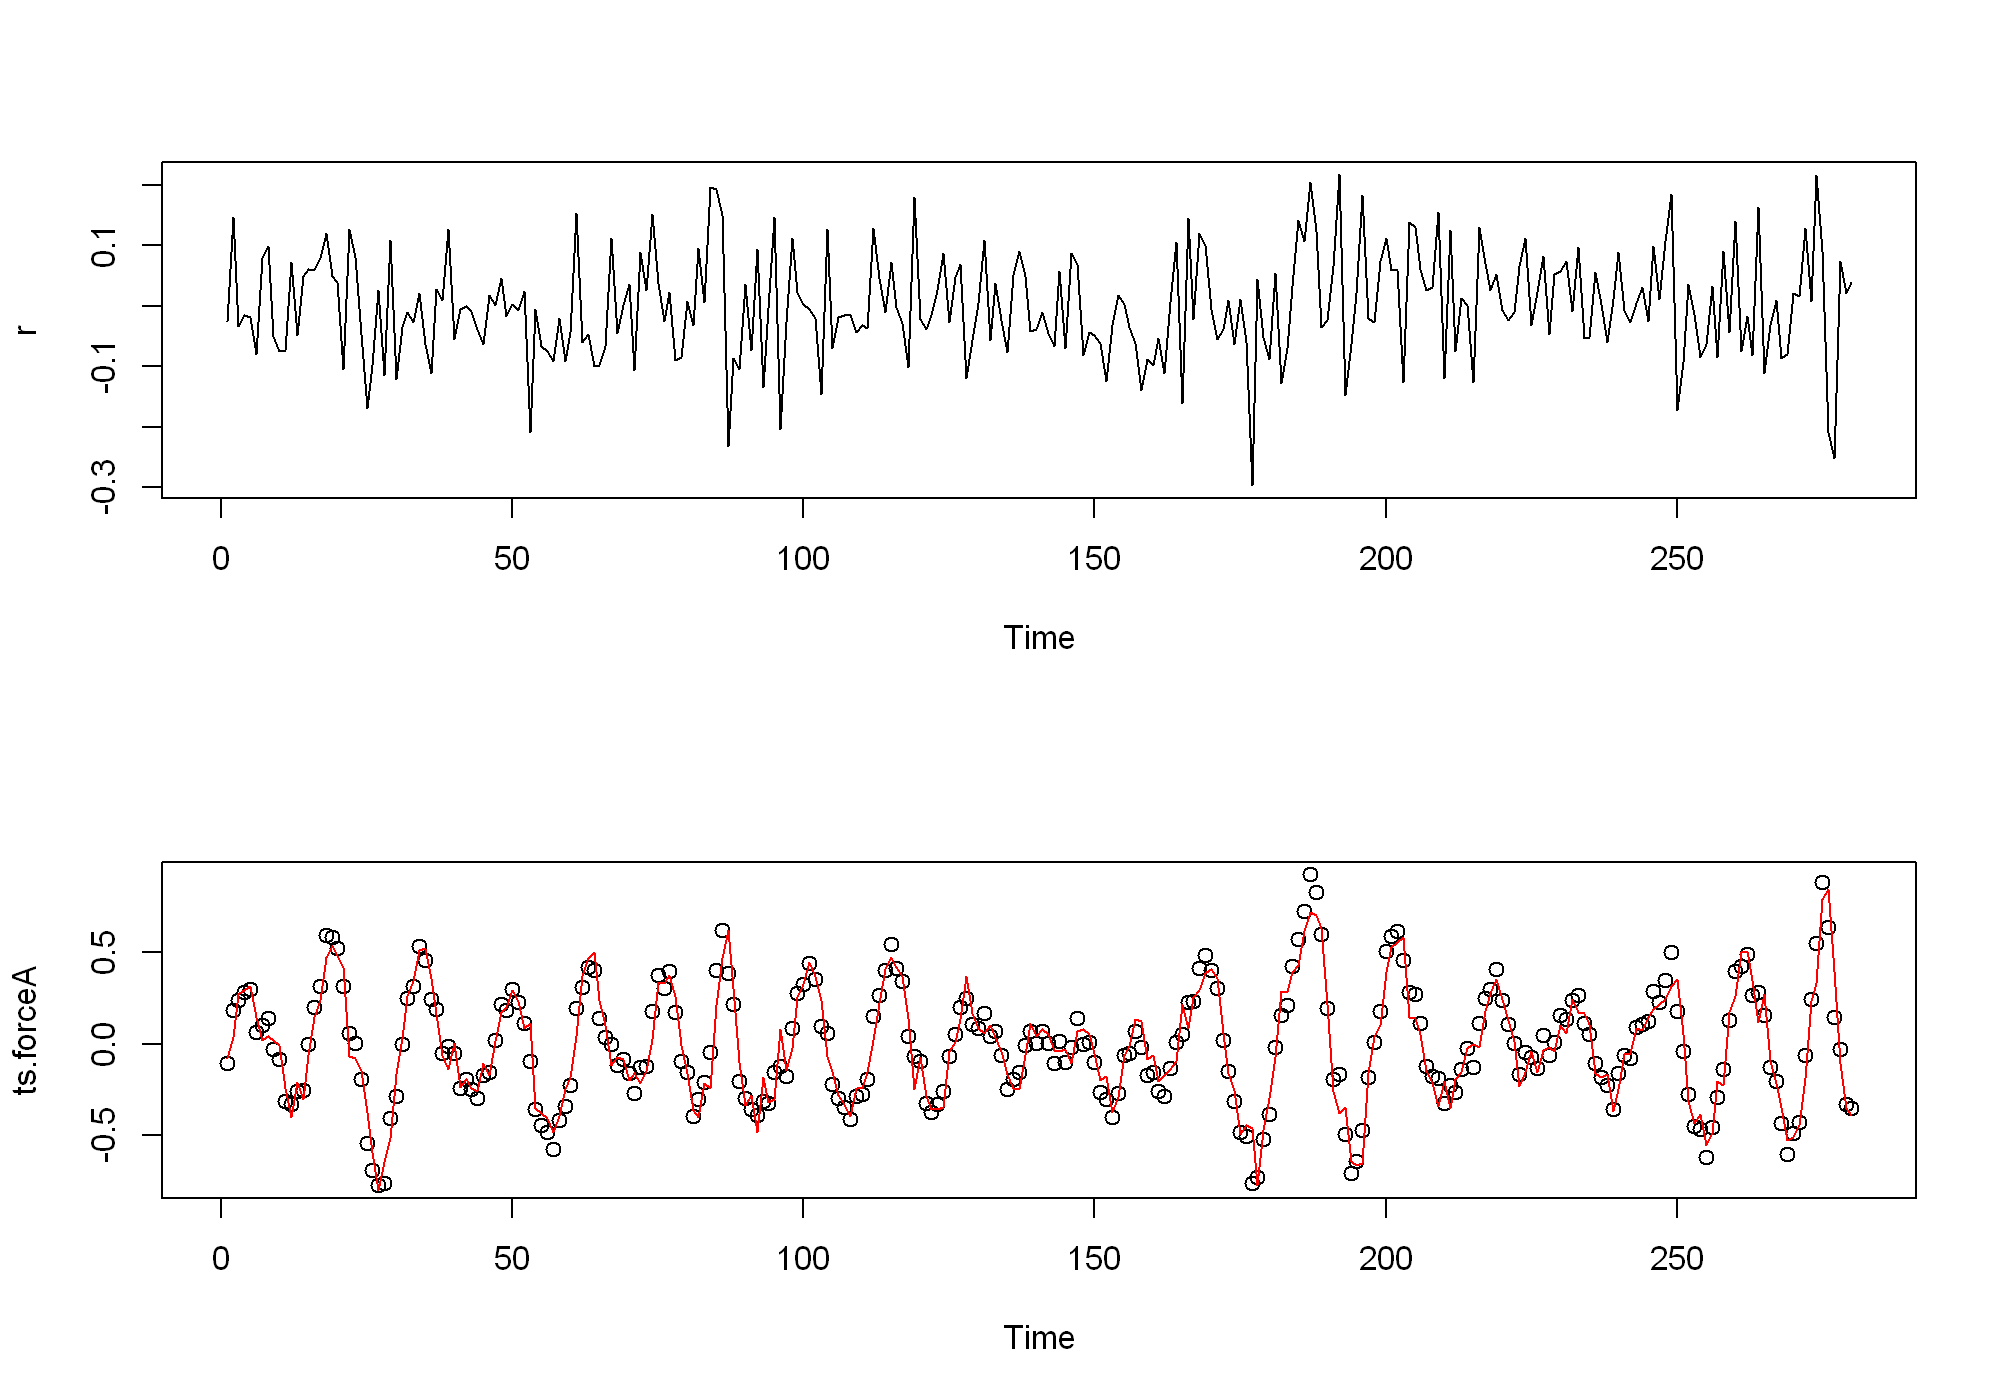

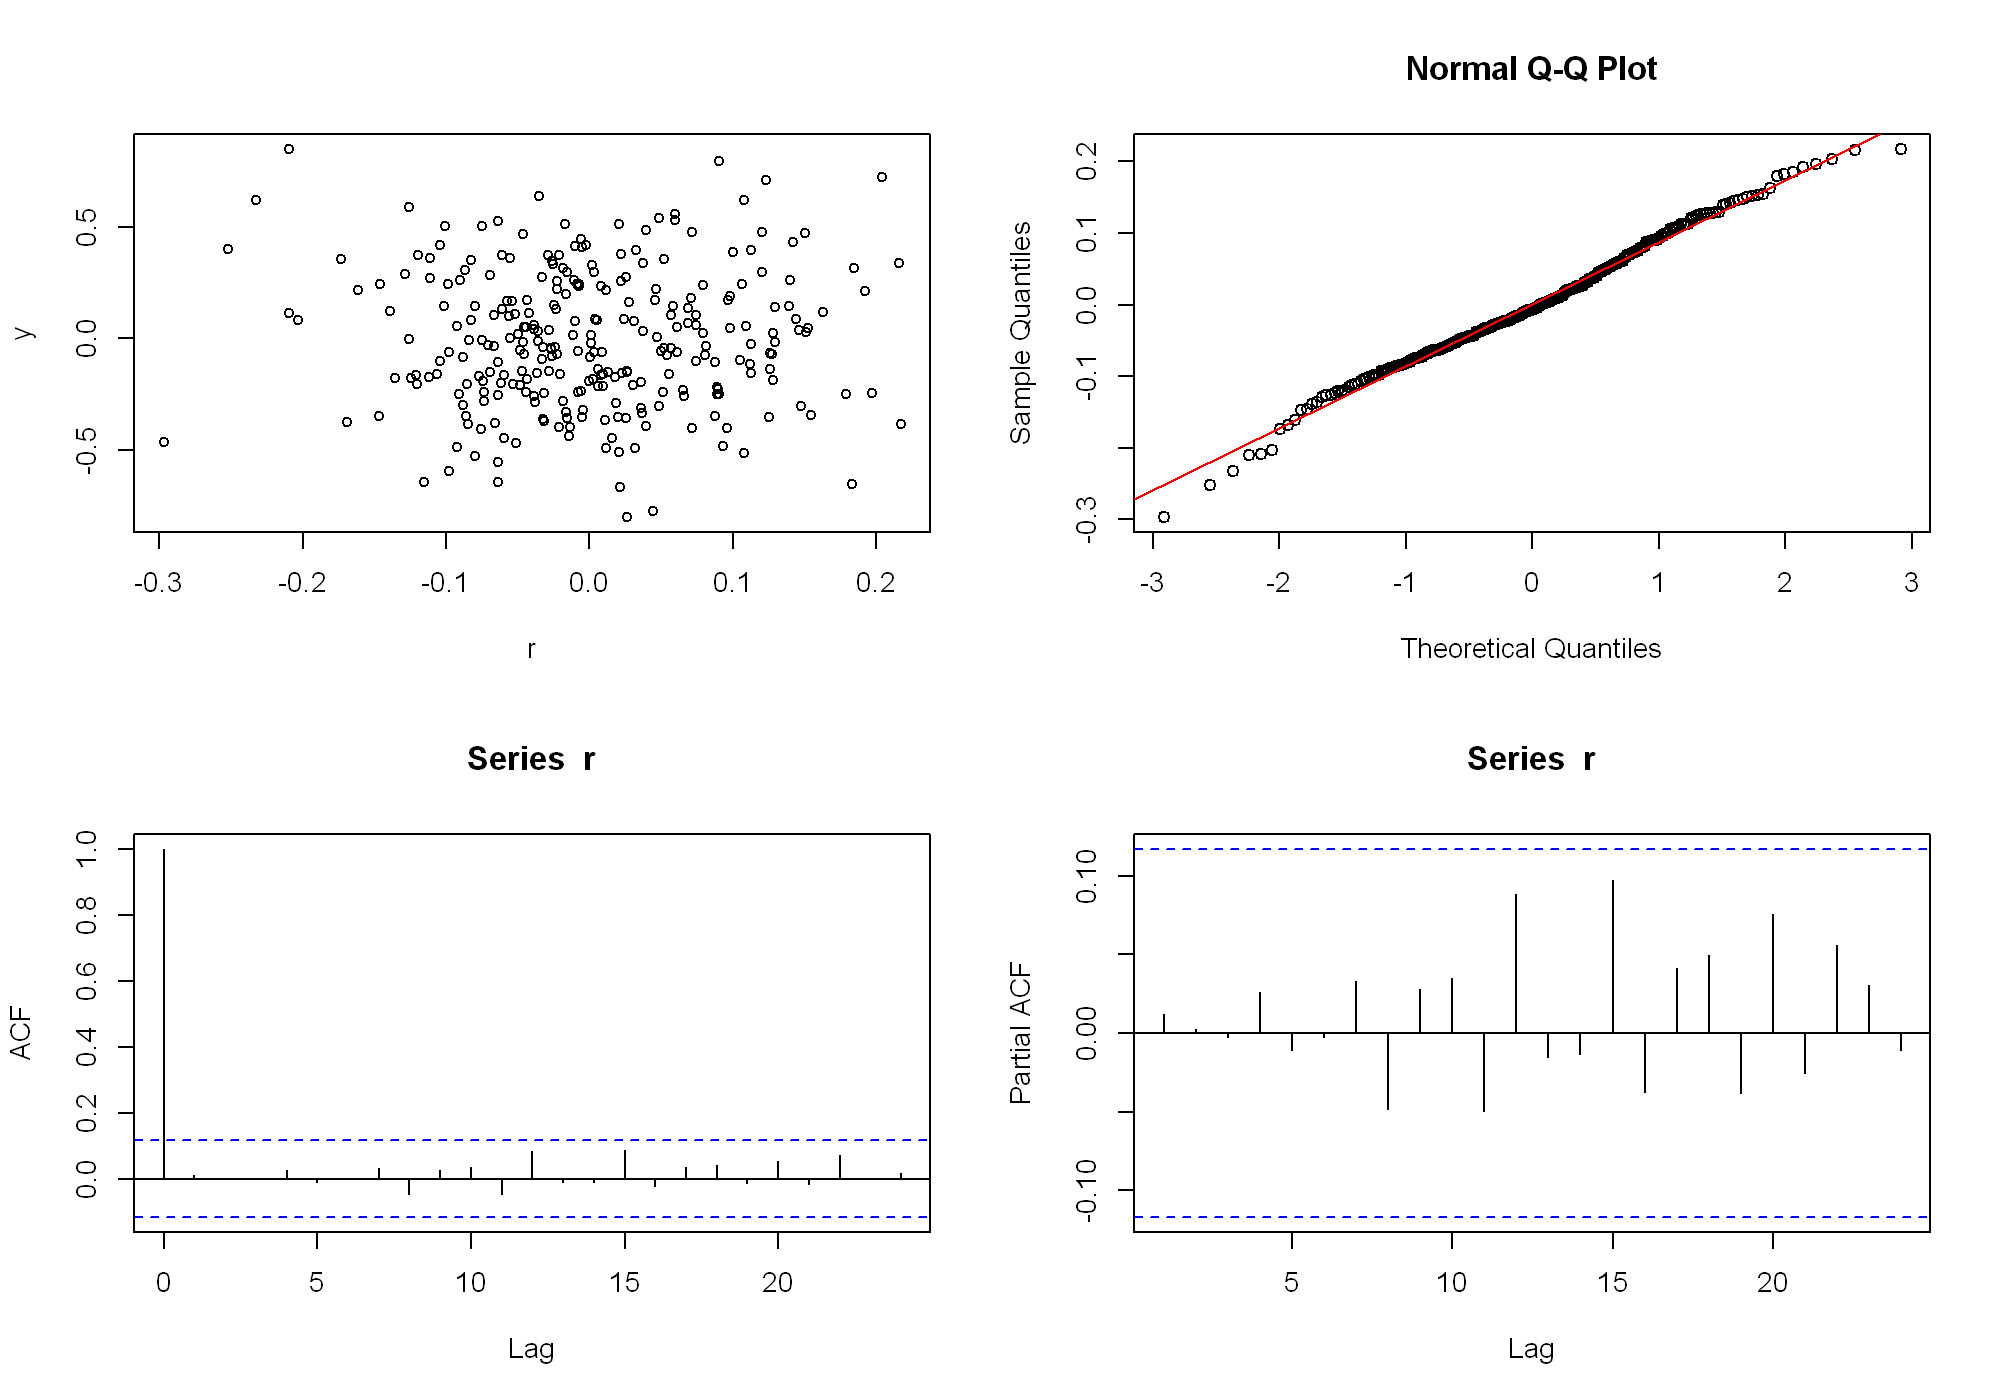

In [13]:
r <- ar.force$residuals
y <- ts.forceA-r
par(mfrow = c(2,1))
plot(r)
plot(ts.forceA,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


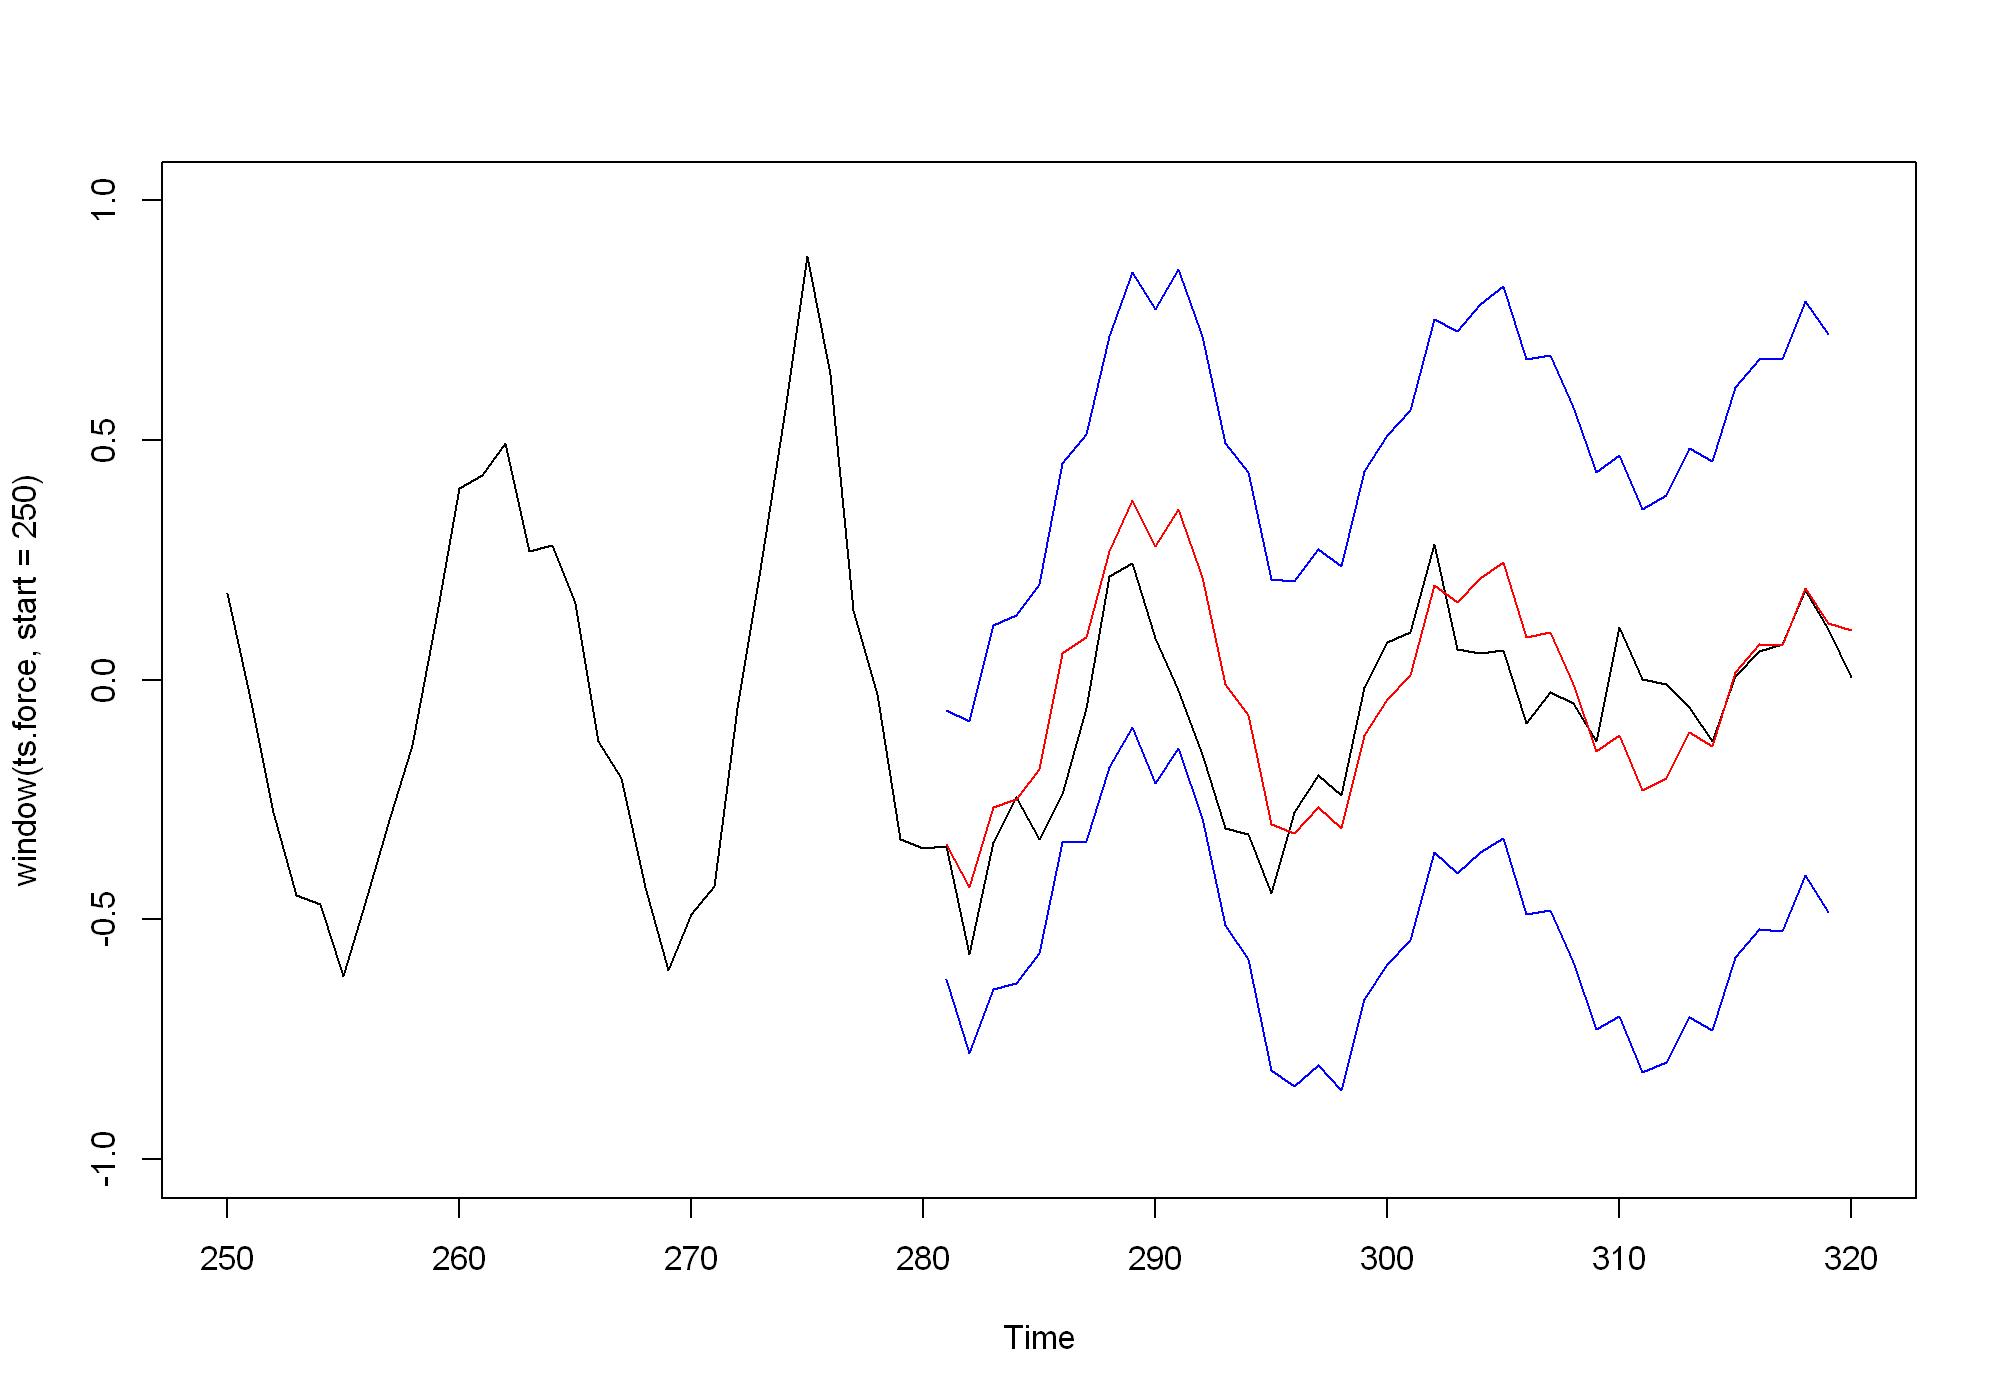

In [14]:
force.pred <- predict(ar.force,n.ahead=40)


CI95 <- ts(qnorm(0.975)*as.numeric(force.pred$se),start=280)



plot(window(ts.force,start=250),ylim=c(-1,1))
lines(force.pred$pred,col="red")
lines(force.pred$pred+CI95,type="l",col="blue")
lines(force.pred$pred-CI95,type="l",col="blue")


In [15]:
d.yields <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/yields.dat",
header = FALSE)
t.yields <- ts(d.yields[, 1])

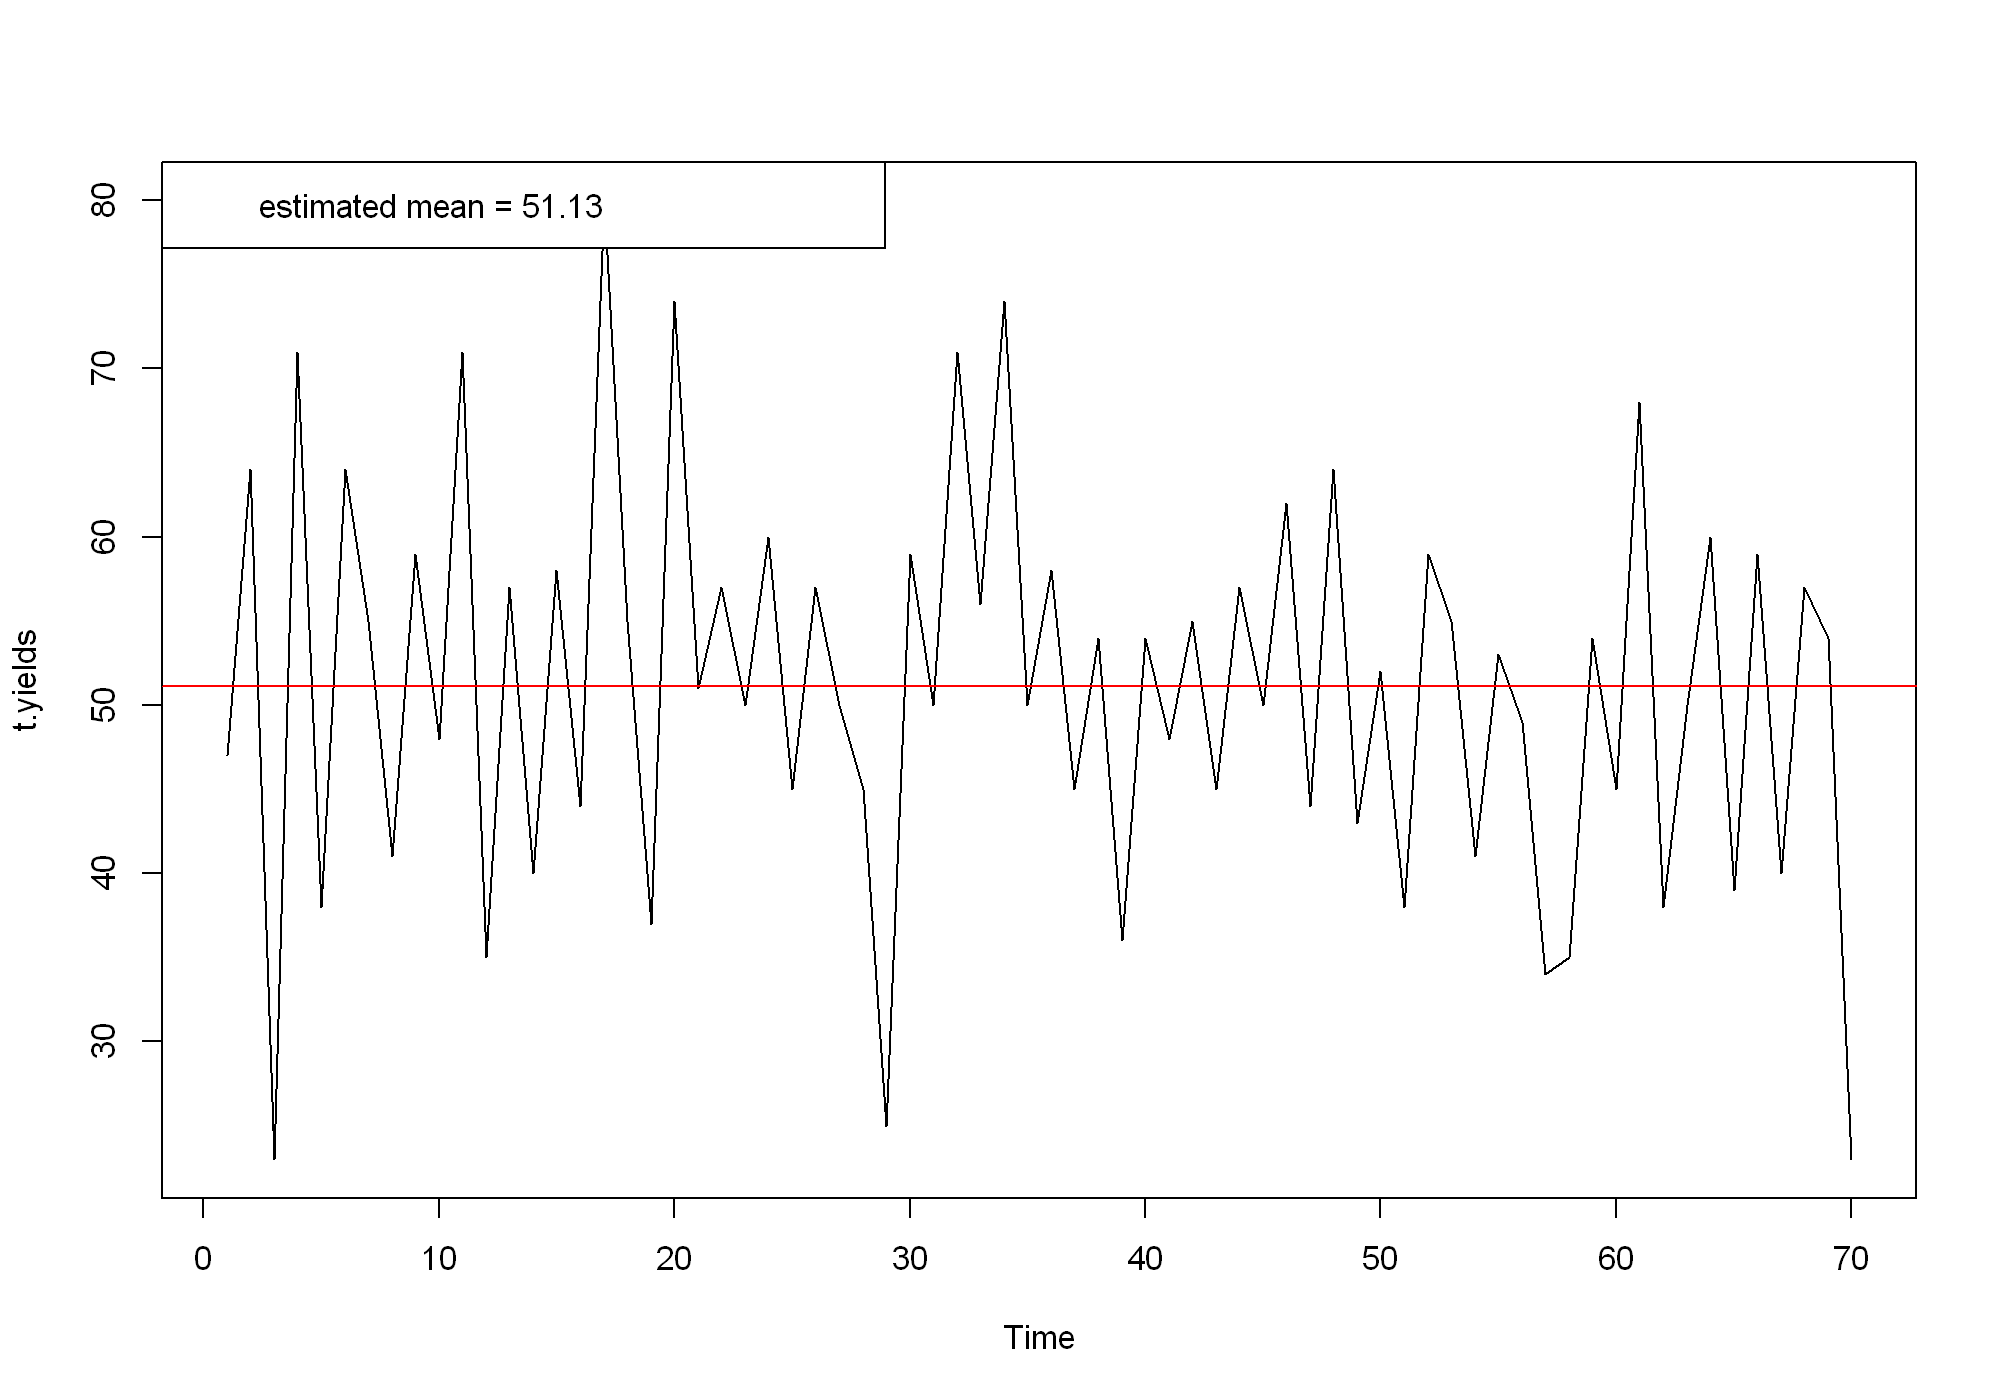

In [16]:
plot(t.yields)
n <- length(t.yields)
mu_hat <- sum(t.yields)/n
abline(h=mu_hat,col="red")
legend("topleft", legend = sprintf("estimated mean = %.2f", mu_hat))


In [17]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

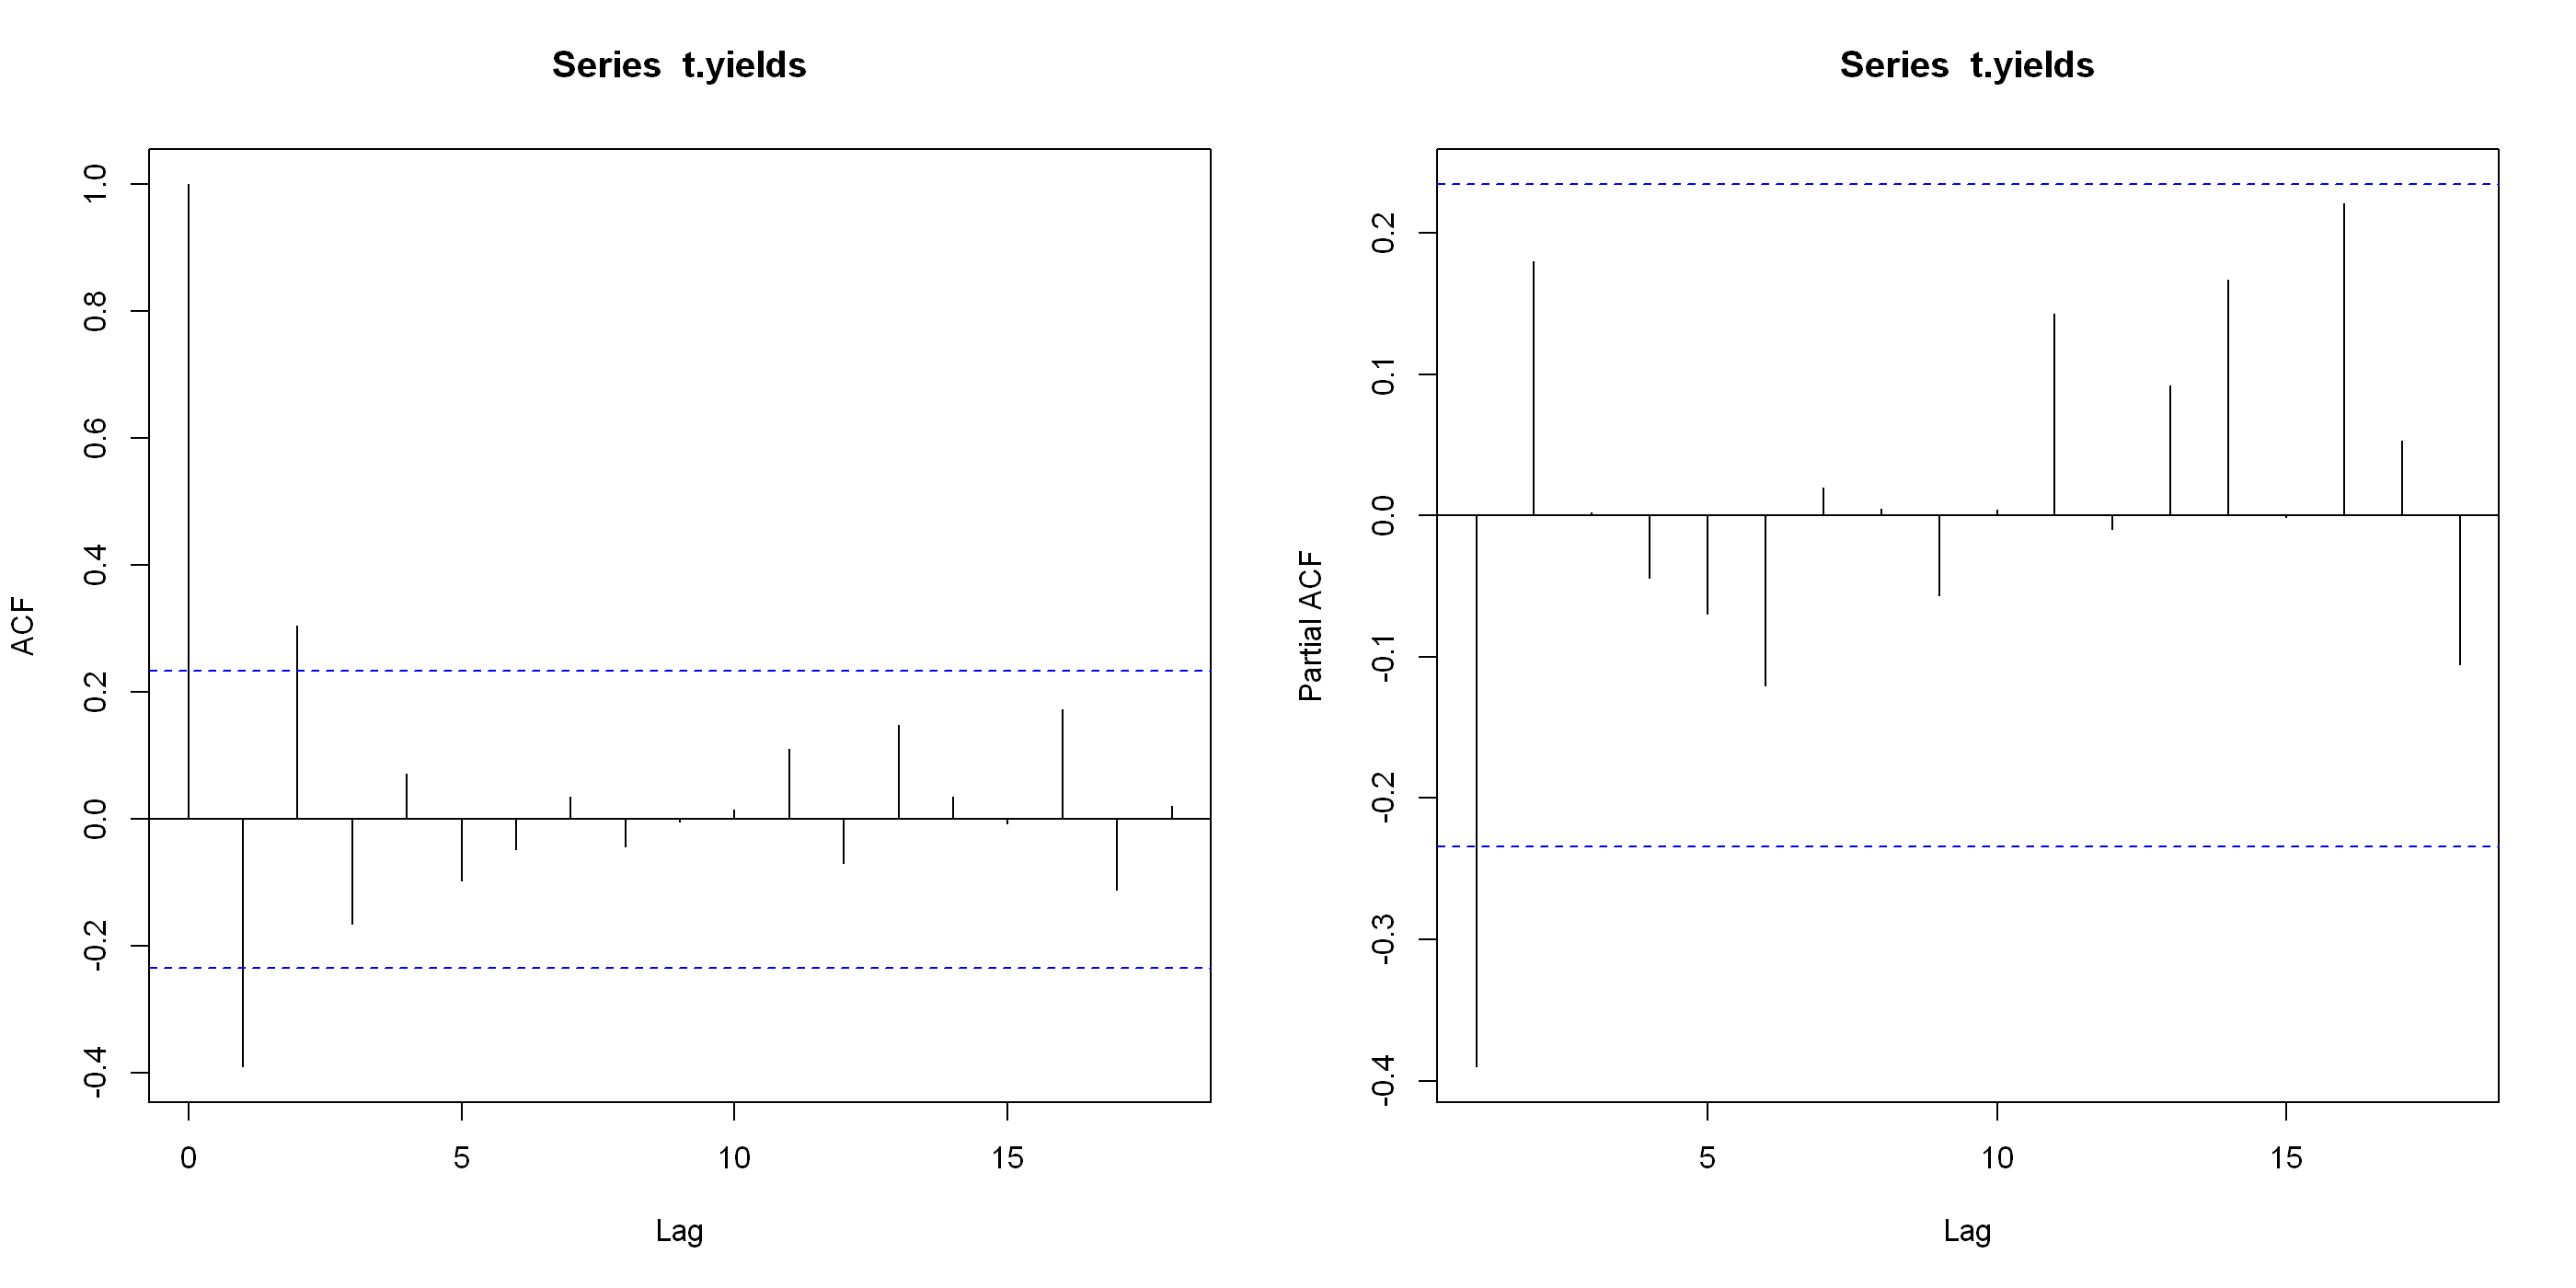

In [18]:
par(mfrow=c(1,2))
acf(t.yields)
pacf(t.yields)

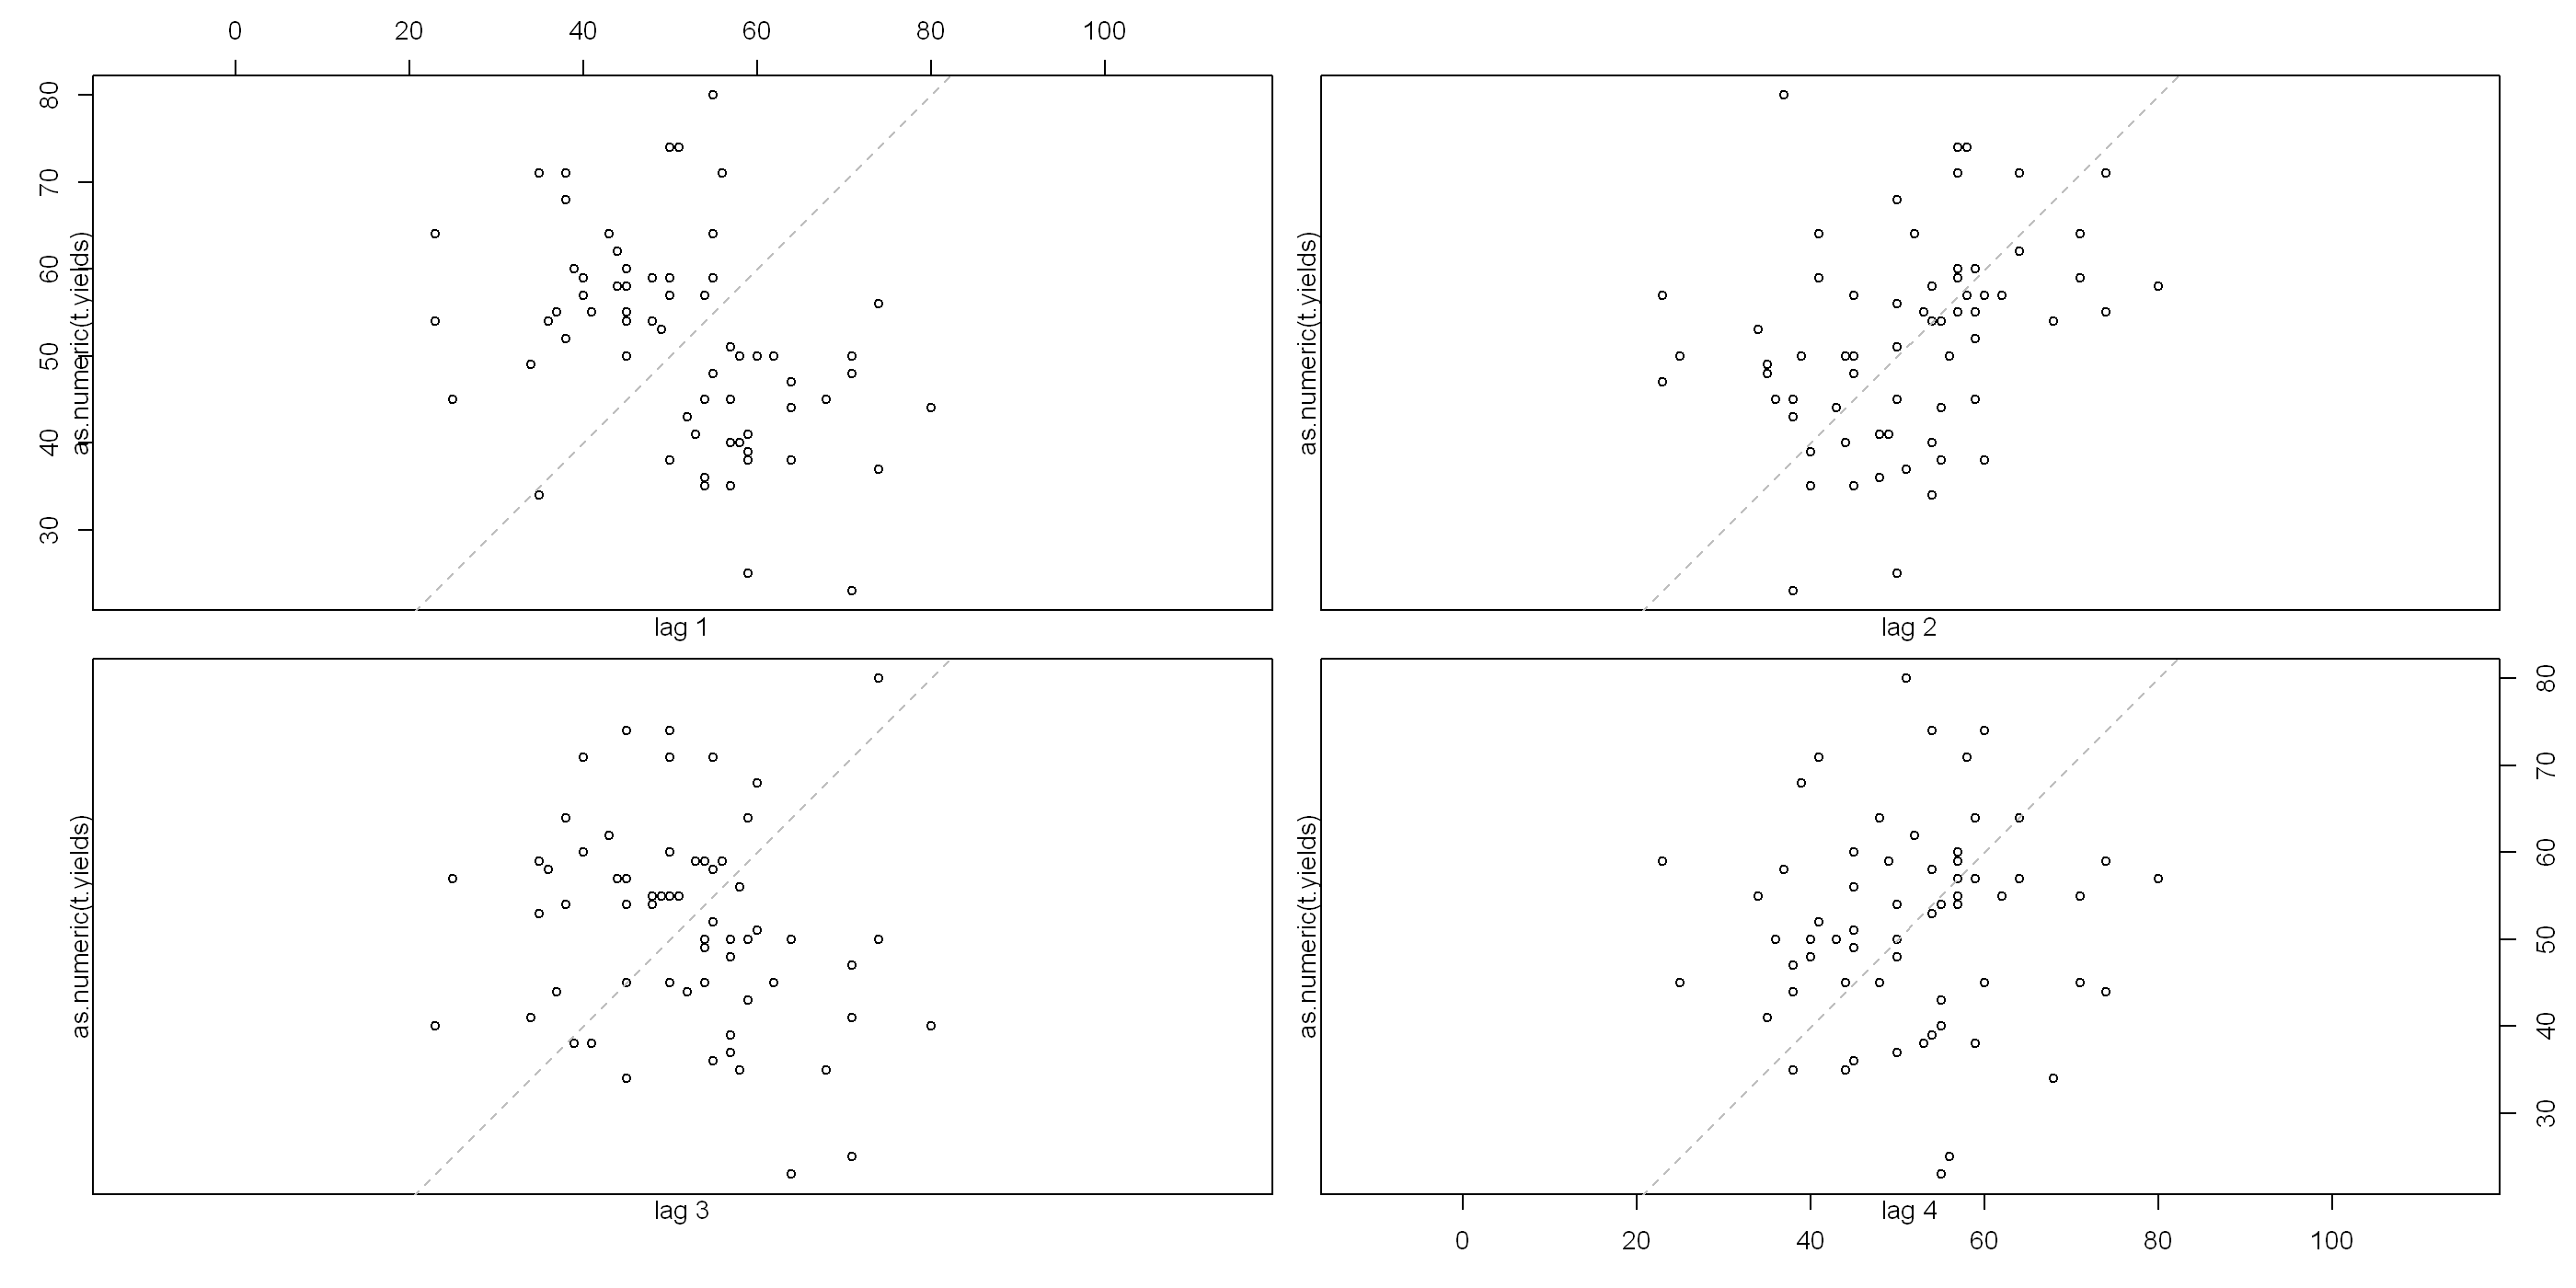

In [19]:
lag.plot(as.numeric(t.yields),lags = 4,type = "p",labels=FALSE, do.lines=FALSE)

In [20]:
gamma0 <- acf(t.yields,type="covariance",plot=F)$acf[1]
n_ <- length(t.yields)
max_lag <- as.integer(10*log10(n_))
acf_ <- acf(t.yields,plot = F,lag.max = max_lag)
acf_2 <- acf(t.yields,plot = F,lag.max = 2)

var_1 <- 0
var_2 <- 0

for (i in seq_len(max_lag)) {
  var_1 <- var_1 + (2*(n_-i)*acf_$acf[i+1])
}

for (i in seq_len(2)) {
  var_2 <- var_2 + (2*(n_-i)*acf_2$acf[i+1])
}

var_1 <- var_1+n_
var_1 <- gamma0*var_1/(n_^2)

var_2 <- var_2+n_
var_2 <- gamma0*var_2/(n_^2)

var_3 <- gamma0/n_

In [21]:
CI1 <- qnorm(0.975)*sqrt(var_1)
CI2 <- qnorm(0.975)*sqrt(var_2)
CI3 <- qnorm(0.975)*sqrt(var_3)

In [22]:
c(mu_hat-CI1,mu_hat+CI1)
c(mu_hat-CI2,mu_hat+CI2)
c(mu_hat-CI3,mu_hat+CI3)

[1] 48.55537 53.70177

[1] 48.61616 53.64098

[1] 48.35877 53.89838

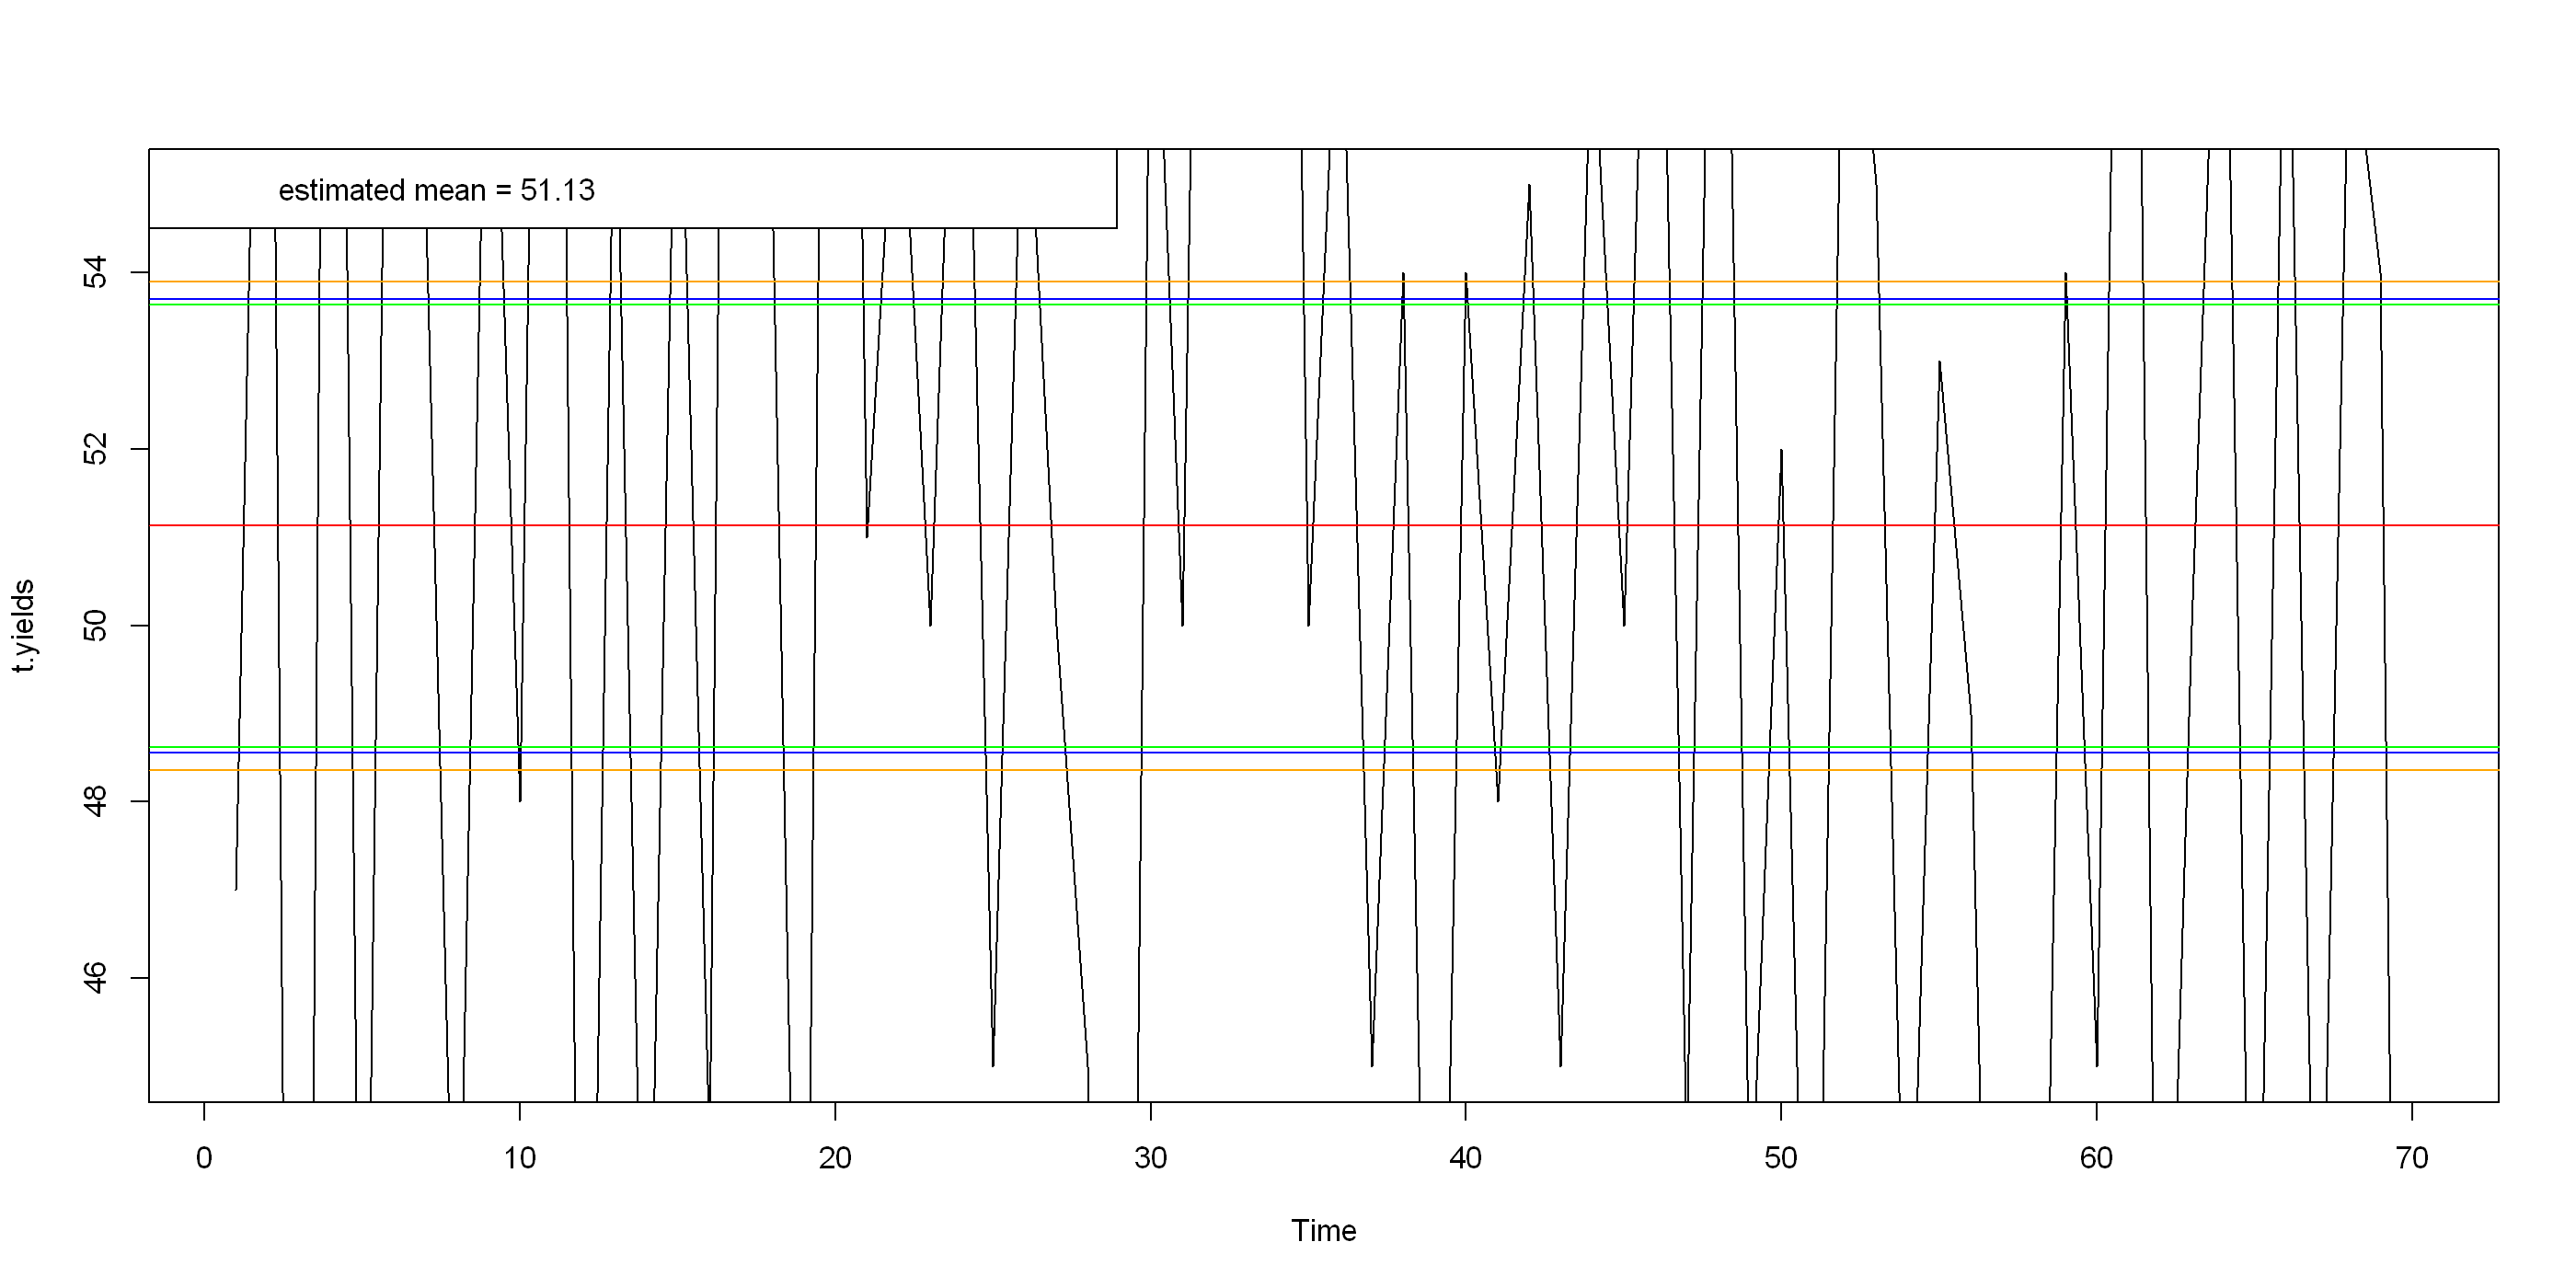

In [23]:

plot(t.yields,ylim=c(45,55))
abline(h=mu_hat,col="red")
legend("topleft", legend = sprintf("estimated mean = %.2f", mu_hat))
abline(h=(mu_hat+CI1),col="blue")
abline(h=(mu_hat-CI1),col="blue")

abline(h=(mu_hat+CI2),col="green")
abline(h=(mu_hat-CI2),col="green")

abline(h=(mu_hat+CI3),col="orange")
abline(h=(mu_hat-CI3),col="orange")